In [157]:
### 히트맵 시각화 라이브러리
### 파이썬에서 가장 기본적으로 사용하는 시각화 라이브러리
import matplotlib.pyplot as plt

### 히트맵 라이브러리
import seaborn as sns

### 한글처리(시각화 시 그래프 내에 한글이 포함되는 경우 한글 깨짐 현상 방지)
plt.rc("font", family="Malgun Gothic")

### 특수기호(마이너스 기호) 처리
plt.rcParams["axes.unicode_minus"] = False

In [158]:
import pandas as pd

In [159]:
import numpy as np


In [160]:
df=pd.read_csv('./merged_recipe_data.csv')

In [161]:
df['RCP_SNO']=df['RCP_SNO'].astype(int)

#재료 추출

In [162]:
df['CKG_MTRL_CN']

0         [재료] 어묵 2개| 김밥용김 3장| 당면 1움큼| 양파 1/2개| 당근 1/2개|...
1         [재료] 두부 1/2모| 당근 1/2개| 고추 2개| 브로콜리 1/4개| 새우 4마...
2         [재료] 밥 1+1/2공기| 당근 1/4개| 치자단무지 1/2개| 신김치 1쪽| 무...
3                  [재료] 현미 4컵| 찹쌀 2컵| 호두 50g| 물 1/2컵| 소금 약간
4         [재료] 북어포 1마리| 찹쌀가루 1C [양념] 간장 2T| 설탕 1T| 물 1T|...
                                ...                        
207494    [재료] 도토리묵700g| 상추10장(또는 쌈채소)| 당근1/2개|...
207495    [주재료] 도토리묵350g| 국물멸치1줌| 다시마1개| 물500...
207496    [재료] 세발나물200g| 소금0.5큰술(데칠용)| 국간장0.5큰술...
207497    [주재료] 대패삼겹살700g| 느타리버섯300g| 양파1/2개| 청...
207498    [재료] 계란7개| 애호박1/4개| 당근1/5개| 쪽파3대(또...
Name: CKG_MTRL_CN, Length: 207499, dtype: object

In [163]:
df['CKG_MTRL_CN']

0         [재료] 어묵 2개| 김밥용김 3장| 당면 1움큼| 양파 1/2개| 당근 1/2개|...
1         [재료] 두부 1/2모| 당근 1/2개| 고추 2개| 브로콜리 1/4개| 새우 4마...
2         [재료] 밥 1+1/2공기| 당근 1/4개| 치자단무지 1/2개| 신김치 1쪽| 무...
3                  [재료] 현미 4컵| 찹쌀 2컵| 호두 50g| 물 1/2컵| 소금 약간
4         [재료] 북어포 1마리| 찹쌀가루 1C [양념] 간장 2T| 설탕 1T| 물 1T|...
                                ...                        
207494    [재료] 도토리묵700g| 상추10장(또는 쌈채소)| 당근1/2개|...
207495    [주재료] 도토리묵350g| 국물멸치1줌| 다시마1개| 물500...
207496    [재료] 세발나물200g| 소금0.5큰술(데칠용)| 국간장0.5큰술...
207497    [주재료] 대패삼겹살700g| 느타리버섯300g| 양파1/2개| 청...
207498    [재료] 계란7개| 애호박1/4개| 당근1/5개| 쪽파3대(또...
Name: CKG_MTRL_CN, Length: 207499, dtype: object

In [164]:
df.loc[207498]

RCP_SNO                                                       7041370
CKG_NM                                                        애호박계란말이
CKG_MTRL_CN         [재료] 계란7개| 애호박1/4개| 당근1/5개| 쪽파3대(또...
CKG_DODF_NM                                                        초급
CKG_MTRL_ACTO_NM                                               달걀/유제품
Name: 207498, dtype: object

In [165]:
df['rec']=df['CKG_MTRL_CN'].str.replace("", " ", regex=True)

In [166]:
df['rec']=df['rec'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)

In [167]:
df['rec']

0         재료 어묵 개 김밥용김 장 당면 움큼 양파 개 당근 개 깻잎 장 튀김가루 컵  올리...
1                  재료 두부 모 당근 개 고추 개 브로콜리 개 새우 마리 녹말가루 계란 개
2         재료 밥 공기 당근 개 치자단무지 개 신김치 쪽 무순 약간 날치알 스푼 김가루 약간...
3                                재료 현미 컵 찹쌀 컵 호두  물 컵 소금 약간
4         재료 북어포 마리 찹쌀가루  양념 간장  설탕  물  다진파  다진마늘  참기름  ...
                                ...                        
207494    재료 도토리묵    상추  장 또는 쌈채소 당근  개  양파  개  신김치  컵  ...
207495    주재료 도토리묵    국물멸치  줌  다시마  개  물    멸치액젓    조미김 ...
207496    재료 세발나물    소금  큰술 데칠용 국간장  큰술  멸치액젓  큰술  참기름  ...
207497    주재료 대패삼겹살    느타리버섯    양파  개  청양고추  개  홍고추  개  ...
207498    재료 계란  개  애호박  개  당근  개  쪽파  대 또는 대파 부추 소금  꼬집...
Name: rec, Length: 207499, dtype: object

In [168]:
non_ingre=['재료','주재료','또는','장','개','물','조금','꼬집',
           '스푼','쪽','양념','웅큼','공기','약간','컵','마리','큰술','작은술','줌',
           '데칠용','다진','적당량','양념만들기','모','대','숟가락','숟갈',
           '수저','알','술','종이컵','소스','팩','종이컵','조각','티스푼',
           '봉지','인분','양념장','큰','뿌리','적당히','줄','그램','정도',
           '통','톡톡','캔','단','봉','톨','베이킹파우더','포기','필수재료','양념재료','줄기'
           ,"종류", "많이", "작은", "번", "기호에 맞게", "삶은", "주먹", "가루", "조각", "조금", "약간",'것']

In [169]:
non_spice=['소금','설탕','참기름','올리브유','고춧가루','고추가루','후추','간장','통깨',
           '식초','고추장','식용유','된장','멸치액젓','국간장','오일','맛술',
           '깨소금','들기름','마요네즈','버터','후춧가루','굴소스','진간장','깨','매실청',
           '물엿','청주','액젓','올리고당','파슬리가루','레몬즙','소주','굵은소금','양념간장',
           '미림','매실액','통깨','참깨','올리브오일','새우젓','양조간장','생강가루','참치액']

쪽을 제거하면 쪽파가 쪽이 됨!

In [170]:
non_ingre_f=non_spice+non_ingre
def remove_non_ingre(text):
    text=text.replace('다진파','대파')
    text=text.replace('간마늘','마늘')
    text=text.replace('다진마늘','마늘')
    text=text.replace('대파','파')
    text=text.replace('통마늘','마늘')
    # 공백 기준으로 단어 분리
    words = text.split()
    # 불용어 리스트에 없는 단어만 남기기
    filtered = [w for w in words if w not in non_ingre_f]
    # 다시 문장으로 합치기
    return filtered

df['rec1'] = df['rec'].apply(remove_non_ingre)

In [171]:
df['rec1']

0                      [어묵, 김밥용김, 당면, 움큼, 양파, 당근, 깻잎, 튀김가루]
1                          [두부, 당근, 고추, 브로콜리, 새우, 녹말가루, 계란]
2         [밥, 당근, 치자단무지, 신김치, 무순, 날치알, 김가루, 후리가케또는밥이랑같은류...
3                                              [현미, 찹쌀, 호두]
4                                        [북어포, 찹쌀가루, 파, 마늘]
                                ...                        
207494                     [도토리묵, 상추, 쌈채소, 당근, 양파, 신김치, 마늘]
207495      [도토리묵, 국물멸치, 다시마, 조미김, 청양고추, 김치양념장, 신김치, 마늘, 꿀]
207496                                           [세발나물, 마늘]
207497    [대패삼겹살, 느타리버섯, 양파, 청양고추, 홍고추, 마늘, 제육볶음, 대게어간장, 꿀]
207498                             [계란, 애호박, 당근, 쪽파, 파, 부추]
Name: rec1, Length: 207499, dtype: object

In [172]:
df.loc[152]

RCP_SNO                                                        554884
CKG_NM                                                            떡볶이
CKG_MTRL_CN         [김말이 튀김] 잡채 2줌| 김 3장| 밀가루 2줌 [떡볶이] 떡국떡 3줌| 어묵 ...
CKG_DODF_NM                                                       아무나
CKG_MTRL_ACTO_NM                                                    쌀
rec                 김말이 튀김 잡채 줌 김 장 밀가루 줌 떡볶이 떡국떡 줌 어묵 장 대파 뿌리 튀김반...
rec1                [김말이, 튀김, 잡채, 김, 밀가루, 떡볶이, 떡국떡, 어묵, 파, 튀김반죽, 튀...
Name: 152, dtype: object

In [173]:
#df[df['rec1'].apply(lambda x: '당근' in x and '양배추' in x and '두부' in x)]

In [174]:
#df.to_csv('test1.csv',index=False)

In [175]:
df['rec1']

0                      [어묵, 김밥용김, 당면, 움큼, 양파, 당근, 깻잎, 튀김가루]
1                          [두부, 당근, 고추, 브로콜리, 새우, 녹말가루, 계란]
2         [밥, 당근, 치자단무지, 신김치, 무순, 날치알, 김가루, 후리가케또는밥이랑같은류...
3                                              [현미, 찹쌀, 호두]
4                                        [북어포, 찹쌀가루, 파, 마늘]
                                ...                        
207494                     [도토리묵, 상추, 쌈채소, 당근, 양파, 신김치, 마늘]
207495      [도토리묵, 국물멸치, 다시마, 조미김, 청양고추, 김치양념장, 신김치, 마늘, 꿀]
207496                                           [세발나물, 마늘]
207497    [대패삼겹살, 느타리버섯, 양파, 청양고추, 홍고추, 마늘, 제육볶음, 대게어간장, 꿀]
207498                             [계란, 애호박, 당근, 쪽파, 파, 부추]
Name: rec1, Length: 207499, dtype: object

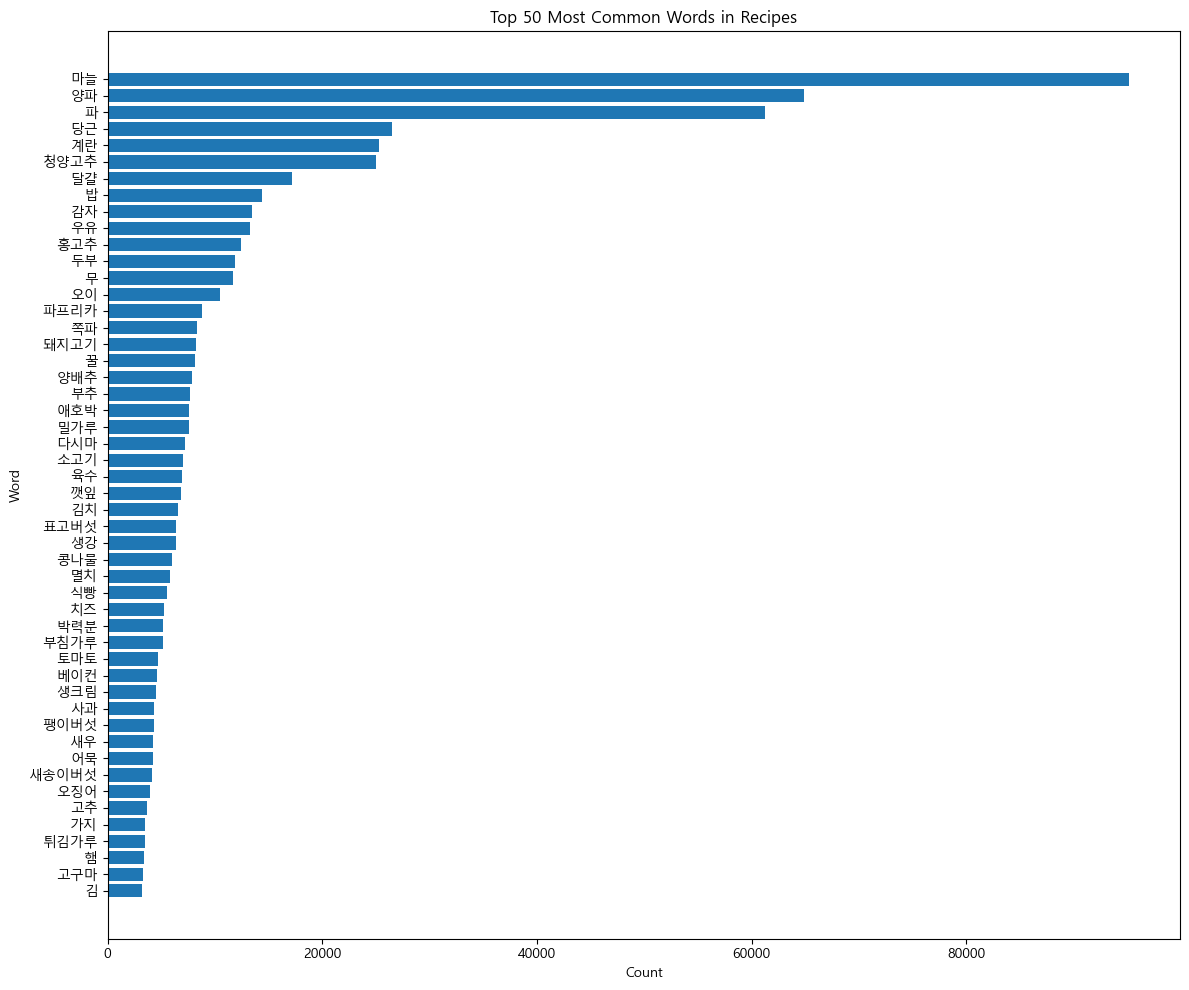

In [183]:
from collections import Counter
import matplotlib.pyplot as plt
from itertools import chain

# 1️⃣ 모든 리스트를 하나로 펼치기 (flatten)
all_words = list(chain.from_iterable(df['rec1']))

# 2️⃣ 단어 빈도 계산
word_counts = Counter(all_words)

# 3️⃣ 상위 100개 단어 추출
top100 = word_counts.most_common(100)

# 4️⃣ DataFrame으로 변환 (시각화에 편리)
import pandas as pd
top100_df = pd.DataFrame(top100, columns=['word', 'count'])
top50_df=top100_df.head(50)
# 5️⃣ 시각화
plt.figure(figsize=(12, 10))
plt.barh(top50_df['word'][::-1], top50_df['count'][::-1])  # 상위 단어를 위쪽에 표시
plt.title('Top 50 Most Common Words in Recipes')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


In [184]:
#통마늘 간마늘을 마늘로 
#다진파를 파로

In [178]:
top100_df['word'][::-1]

99      전분
98    전분가루
97     삼겹살
96    밥숟가락
95      숙주
      ... 
4       계란
3       당근
2        파
1       양파
0       마늘
Name: word, Length: 100, dtype: object

In [179]:
print(top100_df['word'])

0       마늘
1       양파
2        파
3       당근
4       계란
      ... 
95      숙주
96    밥숟가락
97     삼겹살
98    전분가루
99      전분
Name: word, Length: 100, dtype: object


In [180]:
top100_df[top100_df['word']=='간마늘']

,word,count


In [181]:
top100_df

,word,count
0,마늘,95134
1,양파,64850
2,파,61192
3,당근,26477
4,계란,25268
...,...,...
95,숙주,2173
96,밥숟가락,2172
97,삼겹살,2156
98,전분가루,2154


In [182]:
print(top50_df['word'].tolist())

['마늘', '양파', '파', '당근', '계란', '청양고추', '달걀', '밥', '감자', '우유', '홍고추', '두부', '무', '오이', '파프리카', '쪽파', '돼지고기', '꿀', '양배추', '부추', '애호박', '밀가루', '다시마', '소고기', '육수', '깻잎', '김치', '표고버섯', '생강', '콩나물', '멸치', '식빵', '치즈', '박력분', '부침가루', '토마토', '베이컨', '생크림', '사과', '팽이버섯', '새우', '어묵', '새송이버섯', '오징어', '고추', '가지', '튀김가루', '햄', '고구마', '김']


In [189]:
df=df.drop(['CKG_DODF_NM','CKG_MTRL_ACTO_NM','rec'],axis=1)

In [ ]:
#df.to_csv('food_data_final.csv',index=False)